In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import pyttsx3
from collections import deque


import mediapipe as mp
import cv2
from tqdm import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (classification_report, 
                           accuracy_score,
                           confusion_matrix,
                           ConfusionMatrixDisplay)
import xgboost as xgb


In [5]:

# Initialize MediaPipe Hands
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=2,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.7
)


In [6]:

def extract_features(image_path):
    image = cv2.imread(image_path)
    if image is None:
        return None
    
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = hands.process(image_rgb)
    
    if not results.multi_hand_landmarks:
        return None
    
    features = []
    for hand_landmarks in results.multi_hand_landmarks:
        # Basic landmarks (63 features: x,y,z for 21 landmarks)
        landmark_list = []
        for lm in hand_landmarks.landmark:
            landmark_list.extend([lm.x, lm.y, lm.z])
        
        # 1. Distances between key points
        thumb_tip = np.array([hand_landmarks.landmark[4].x, hand_landmarks.landmark[4].y])
        index_tip = np.array([hand_landmarks.landmark[8].x, hand_landmarks.landmark[8].y])
        thumb_index_dist = np.linalg.norm(thumb_tip - index_tip)
        
        # 2. Palm width
        palm_width = np.linalg.norm(
            np.array([hand_landmarks.landmark[0].x, hand_landmarks.landmark[0].y]) -
            np.array([hand_landmarks.landmark[5].x, hand_landmarks.landmark[5].y])
        )
        
        # 3. Finger lengths
        index_length = np.linalg.norm(
            np.array([hand_landmarks.landmark[5].x, hand_landmarks.landmark[5].y]) -
            np.array([hand_landmarks.landmark[8].x, hand_landmarks.landmark[8].y])
        )
        
        features = landmark_list + [thumb_index_dist, palm_width, index_length]
    
    return features


In [25]:

def process_dataset(data_dir, max_samples_per_class=None):
    data = []
    labels = []
    failed_images = 0
    
    data_path = Path(data_dir)
    if not data_path.exists():
        raise FileNotFoundError(f"Dataset directory not found: {data_path}")
    
    # Process each letter folder
    for label_dir in tqdm(sorted(data_path.iterdir()), desc="Processing letters"):
        if not label_dir.is_dir():
            continue
            
        label = label_dir.name
        img_paths = list(label_dir.glob("*.jpg"))
        
        # Apply sample limit if specified
        if max_samples_per_class is not None:
            img_paths = img_paths[:max_samples_per_class]
        
        # Process each image in the folder
        for img_path in tqdm(img_paths, desc=f"Processing {label}", leave=False):
            features = extract_features(str(img_path))
            if features is not None:
                data.append(features)
                labels.append(label)
            else:
                failed_images += 1
    
    print(f"\nFailed to process {failed_images} images (no hands detected)")
    return np.array(data), np.array(labels)


In [26]:

def train_xgboost_model(X, y):
    # Encode labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
    
    # XGBoost parameter grid
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [3, 6, 9],
        'learning_rate': [0.01, 0.1],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
    
    # Initialize XGBoost
    xgb_model = xgb.XGBClassifier(
        objective='multi:softmax',
        num_class=26,
        eval_metric='mlogloss',
        early_stopping_rounds=10,
        random_state=42
    )
    
    # Grid search
    grid_search = GridSearchCV(
        xgb_model,
        param_grid,
        cv=3,
        n_jobs=-1,
        verbose=1
    )
    
    print("\nStarting hyperparameter tuning...")
    grid_search.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=True)
    
    # Best model
    best_model = grid_search.best_estimator_
    print(f"\nBest parameters: {grid_search.best_params_}")
    
    # Evaluation
    y_pred = best_model.predict(X_test)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
    
    # Confusion matrix
    plt.figure(figsize=(15, 15))
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=90)
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
    
    return best_model, le

def save_model(model, label_encoder, model_path='asl_xgboost_model.pkl'):
    """Save trained model and label encoder"""
    with open(model_path, 'wb') as f:
        pickle.dump({
            'model': model,
            'label_encoder': label_encoder
        }, f)
    print(f"\nModel saved to {model_path}")


Starting feature extraction...


Processing letters: 100%|██████████| 29/29 [34:01<00:00, 70.40s/it]



Failed to process 5013 images (no hands detected)

Training XGBoost model...

Starting hyperparameter tuning...
Fitting 3 folds for each of 48 candidates, totalling 144 fits
[0]	validation_0-mlogloss:2.70695
[1]	validation_0-mlogloss:2.39186
[2]	validation_0-mlogloss:2.15620
[3]	validation_0-mlogloss:1.97908
[4]	validation_0-mlogloss:1.82847
[5]	validation_0-mlogloss:1.70025
[6]	validation_0-mlogloss:1.59177
[7]	validation_0-mlogloss:1.49535
[8]	validation_0-mlogloss:1.40872
[9]	validation_0-mlogloss:1.32848
[10]	validation_0-mlogloss:1.25744
[11]	validation_0-mlogloss:1.19205
[12]	validation_0-mlogloss:1.13146
[13]	validation_0-mlogloss:1.07779
[14]	validation_0-mlogloss:1.02659
[15]	validation_0-mlogloss:0.98001
[16]	validation_0-mlogloss:0.93596
[17]	validation_0-mlogloss:0.89521
[18]	validation_0-mlogloss:0.85700
[19]	validation_0-mlogloss:0.82051
[20]	validation_0-mlogloss:0.78617
[21]	validation_0-mlogloss:0.75477
[22]	validation_0-mlogloss:0.72570
[23]	validation_0-mlogloss:0.6

<Figure size 1500x1500 with 0 Axes>

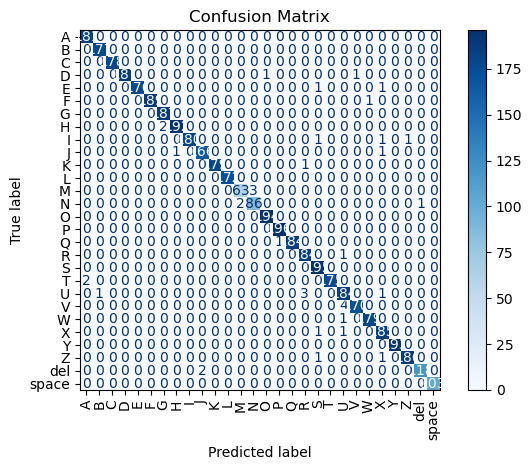


Model saved to asl_xgboost_model.pkl


In [27]:

if __name__ == "__main__":
    
    DATA_DIR = "asl_alphabet_dataset/asl_alphabet_train"
    MODEL_PATH = "asl_xgboost_model.pkl"
    
    try:
        print("Starting feature extraction...")
        X, y = process_dataset(DATA_DIR, max_samples_per_class=1000)  # Now properly implemented
        
        print("\nTraining XGBoost model...")
        model, le = train_xgboost_model(X, y)
        
        save_model(model, le, MODEL_PATH)
        
    except Exception as e:
        print(f"\nError encountered: {str(e)}")
        print("Please check:")
        print(f"1. Dataset path exists: {DATA_DIR}")
        print("2. You have enough memory for processing")
        print("3. Required packages are installed")
    finally:
        # Clean up MediaPipe resources
        hands.close()

In [7]:
def real_time_prediction(model_path='Models\ASL_alphabet_models/asl_xgboost_model.pkl'):
    # Load the trained model
    with open(model_path, 'rb') as f:
        saved_data = pickle.load(f)
        model = saved_data['model']
        label_encoder = saved_data['label_encoder']
    
    # Initialize MediaPipe Hands
    mp_hands = mp.solutions.hands
    hands = mp_hands.Hands(
        static_image_mode=False,
        max_num_hands=1,
        min_detection_confidence=0.8,
        min_tracking_confidence=0.8
    )
    
    # Initialize webcam
    cap = cv2.VideoCapture(0)

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        # Flip frame horizontally for mirror effect
        frame = cv2.flip(frame, 1)
        
        # Convert to RGB
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Process with MediaPipe
        results = hands.process(rgb)
        
        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                # Extract features (must match training exactly)
                features = []
                # 1. Basic landmarks (x,y,z coordinates)
                for lm in hand_landmarks.landmark:
                    features.extend([lm.x, lm.y, lm.z])
                
                # 2. Additional geometric features (same as training)
                thumb_tip = np.array([hand_landmarks.landmark[4].x, hand_landmarks.landmark[4].y])
                index_tip = np.array([hand_landmarks.landmark[8].x, hand_landmarks.landmark[8].y])
                thumb_index_dist = np.linalg.norm(thumb_tip - index_tip)
                
                palm_width = np.linalg.norm(
                    np.array([hand_landmarks.landmark[0].x, hand_landmarks.landmark[0].y]) -
                    np.array([hand_landmarks.landmark[5].x, hand_landmarks.landmark[5].y])
                )
                
                index_length = np.linalg.norm(
                    np.array([hand_landmarks.landmark[5].x, hand_landmarks.landmark[5].y]) -
                    np.array([hand_landmarks.landmark[8].x, hand_landmarks.landmark[8].y])
                )
                
                features = features + [thumb_index_dist, palm_width, index_length]
                
                # Predict
                features_array = np.array(features).reshape(1, -1)
                pred = model.predict(features_array)
                pred_letter = label_encoder.inverse_transform(pred)[0]
                
                # Get hand bounding box
                h, w, _ = frame.shape
                x_coords = [lm.x * w for lm in hand_landmarks.landmark]
                y_coords = [lm.y * h for lm in hand_landmarks.landmark]
                
                # Draw results
                x1, y1 = int(min(x_coords)), int(min(y_coords))
                x2, y2 = int(max(x_coords)), int(max(y_coords))
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(frame, pred_letter, (x1, y1-10), 
                           cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        
        # Display
        cv2.imshow('ASL Detection', frame)
        
        # Exit on 'q' key
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    cap.release()
    cv2.destroyAllWindows()
    hands.close()

In [9]:
real_time_prediction('Models\ASL_alphabet_models/asl_xgboost_model.pkl')